In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

In [3]:
def engineer_features(df):
    df = df.copy()

      
    # 1. Extract Title from Name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
    )
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # 2. Family Features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # 3. Fill missing Age with medeian per PClass + Title Group
    df['Age'] = df.groupby(['Pclass', 'Title'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )

    # 4. Fill missing embarked with mode
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # 5. Log Transform Fare
    df['Fare_log'] = np.log1p(df['Fare'])

    # 6. Drop columns that carry no signal
    df = df.drop(['PassengerId','Name','Ticket','Cabin','Fare','SibSp','Parch'], axis=1)

    return df

df_engineered = engineer_features(df)
print("Shape after engineering:", df_engineered.shape)
print(df_engineered.head())
print("\nMissing values:\n", df_engineered.isnull().sum())

Shape after engineering: (891, 9)
   Survived  Pclass     Sex   Age Embarked Title  FamilySize  IsAlone  \
0         0       3    male  22.0        S    Mr           2        0   
1         1       1  female  38.0        C   Mrs           2        0   
2         1       3  female  26.0        S  Miss           1        1   
3         1       1  female  35.0        S   Mrs           2        0   
4         0       3    male  35.0        S    Mr           1        1   

   Fare_log  
0  2.110213  
1  4.280593  
2  2.188856  
3  3.990834  
4  2.202765  

Missing values:
 Survived      0
Pclass        0
Sex           0
Age           0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
Fare_log      0
dtype: int64


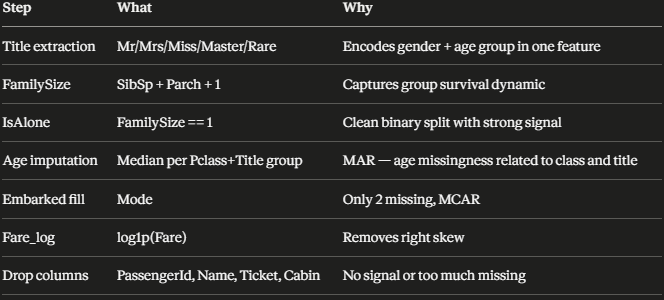

In [4]:
def encode_features(df):
    df = df.copy()
    df['Age'] = (df['Age'] == 'female').astype(int)

    #One-hot encode Title and Embarked
    df = pd.get_dummies(df, columns=['Title', 'Embarked'], drop_first=True)
    return df

df_encoded = encode_features(df_engineered)
print(df_encoded.shape)
print(list(df_encoded.columns))

(891, 13)
['Survived', 'Pclass', 'Sex', 'Age', 'FamilySize', 'IsAlone', 'Fare_log', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Embarked_Q', 'Embarked_S']


In [5]:
print(df_encoded.dtypes)

Survived        int64
Pclass          int64
Sex            object
Age             int64
FamilySize      int64
IsAlone         int64
Fare_log      float64
Title_Miss       bool
Title_Mr         bool
Title_Mrs        bool
Title_Rare       bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [6]:
# Fix Sex encoding

df_encoded['Sex'] = (df_encoded['Sex'] == 'female').astype(int)

# Fix bool columns to int

bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(df_encoded.dtypes)

Survived        int64
Pclass          int64
Sex             int64
Age             int64
FamilySize      int64
IsAlone         int64
Fare_log      float64
Title_Miss      int64
Title_Mr        int64
Title_Mrs       int64
Title_Rare      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


In [7]:
X = df_encoded.drop('Survived', axis=1).values
y = df_encoded['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Survival rate in train:", y_train.mean().round(3))
print("Survival rate in test:", y_test.mean().round(3))

X_train: (712, 12)
X_test: (179, 12)
Survival rate in train: 0.383
Survival rate in test: 0.385


In [8]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    # Cross validation — 5 fold
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    # Train on full training set
    model.fit(X_train, y_train)
    
    # Test set evaluation
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    
    # AUC score
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'CV Mean': cv_scores.mean().round(4),
        'CV Std': cv_scores.std().round(4),
        'Test Accuracy': round(test_acc, 4),
        'AUC': round(auc, 4)
    }
    
    print(f"\n{name}")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  AUC: {auc:.4f}")


Logistic Regression
  CV Accuracy: 0.8133 ± 0.0272
  Test Accuracy: 0.8380
  AUC: 0.8713

Random Forest
  CV Accuracy: 0.7979 ± 0.0348
  Test Accuracy: 0.7877
  AUC: 0.8165


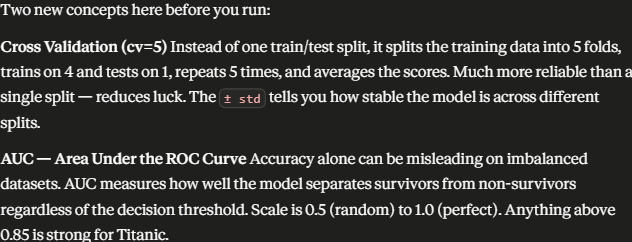

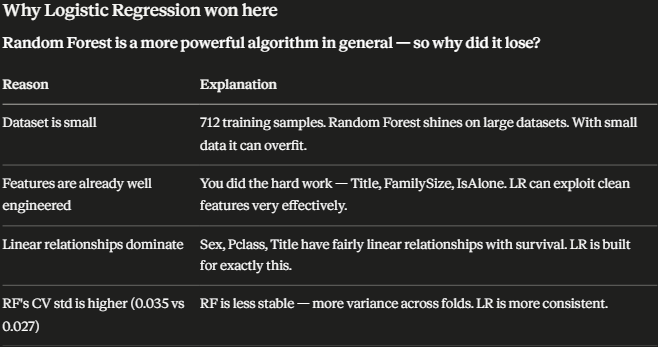
### The lesson: More complex model ≠ better results. Always try simple models first. Logistic Regression on well-engineered features often beats complex models on small structured datasets.

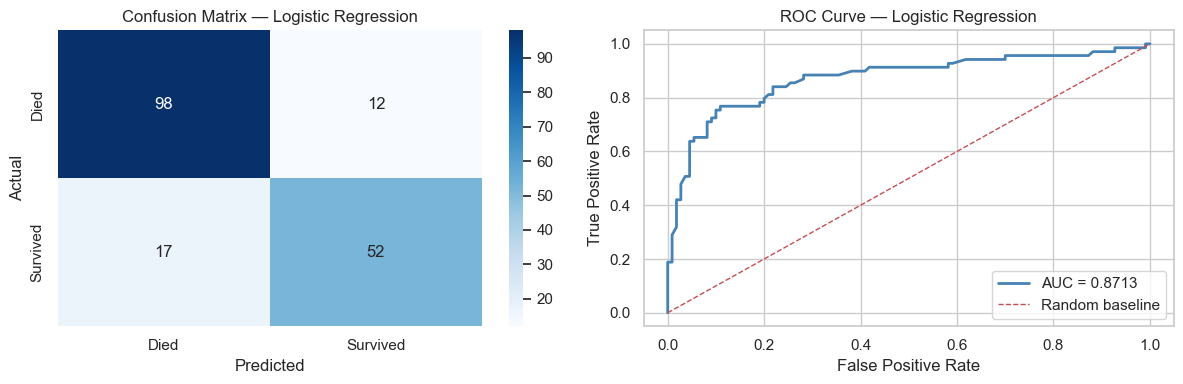

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Use best model — Logistic Regression
best_model = models['Logistic Regression']
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, 
             label=f'AUC = 0.8713')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()

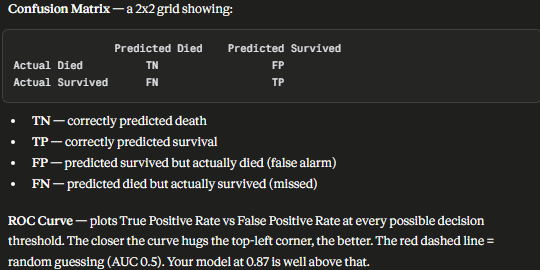

- True Negatives  (correctly predicted death)    = 98
- False Positives (predicted survival, actually died) = 12  
- False Negatives (predicted death, actually survived) = 17
- True Positives  (correctly predicted survival) = 52

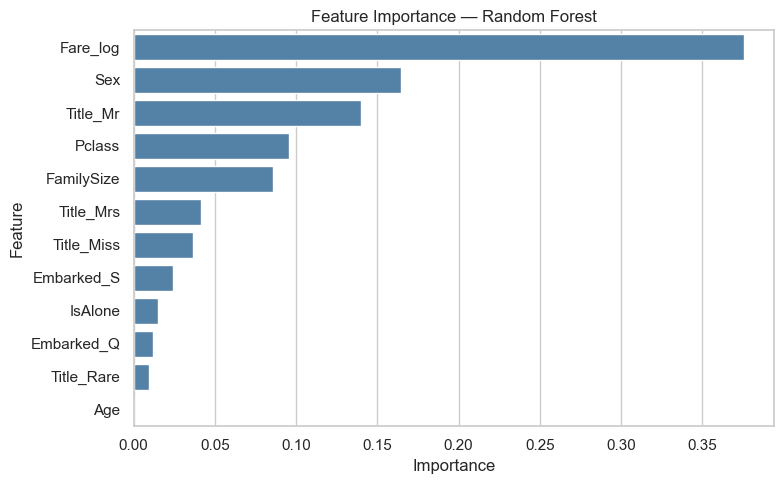

       Feature  Importance
5     Fare_log    0.375321
1          Sex    0.164741
7     Title_Mr    0.139753
0       Pclass    0.095717
3   FamilySize    0.085711
8    Title_Mrs    0.041735
6   Title_Miss    0.036452
11  Embarked_S    0.024106
4      IsAlone    0.015169
10  Embarked_Q    0.011813
9   Title_Rare    0.009483
2          Age    0.000000


In [10]:
feature_names = df_encoded.drop('Survived', axis=1).columns
importances = models['Random Forest'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print(feat_imp)

In [11]:
import joblib

joblib.dump(models['Logistic Regression'], '../titanic_model.pkl')
joblib.dump(scaler, '../titanic_scaler.pkl')

# Save feature columns for Flask
import json
feature_cols = list(df_encoded.drop('Survived', axis=1).columns)
with open('../feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("Saved: titanic_model.pkl, titanic_scaler.pkl, feature_cols.json")
print("Features:", feature_cols)

Saved: titanic_model.pkl, titanic_scaler.pkl, feature_cols.json
Features: ['Pclass', 'Sex', 'Age', 'FamilySize', 'IsAlone', 'Fare_log', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Embarked_Q', 'Embarked_S']
